# Test Pipeline in JupyterLab

This notebook helps test the modular pipeline we've created.

In [1]:
# Import necessary modules
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
%matplotlib inline

# Add the directory containing our modules to path
# Adjust this if your modules are in a different location
module_path = '.'
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
# Import our custom modules
from data_loader import load_data, create_output_directories, get_target_lists
from feature_selection import EnsembleFeatureSelector, create_feature_selection_pipeline
from model_training import process_target
from prediction import make_predictions

## Configuration

In [3]:
# Set parameters
include_covariates = False
method = 'CatBoost'  # Feature selection method
data_dir = '../03_prediction_model/data/raw_data/'  # Directory containing data files
output_dir = './output_20250307'  # Directory for output files
verbose = 1  # Verbosity level

# Create output directories
create_output_directories(output_dir)

# Check if GPU is available
use_gpu = torch.cuda.is_available()
print(f"Include covariates in models: {include_covariates}")
print(f"Feature selection method: {method}")
print(f"Data directory: {data_dir}")
print(f"Output directory: {output_dir}")
print(f"GPU available and will be used: {use_gpu}")

Created output directories in ./output_20250307
Include covariates in models: False
Feature selection method: CatBoost
Data directory: ../03_prediction_model/data/raw_data/
Output directory: ./output_20250307
GPU available and will be used: True


## Load Data

In [4]:
# Load the data
try:
    data = load_data(data_dir, include_covariates)
    print("Data loaded successfully!")
except Exception as e:
    print(f"Error loading data: {e}")

Loaded predictor annotation: 124949 predictors annotated
Loaded X data: 124949 features, 1281 samples
Loaded Y data: 626 targets, 1281 samples
Sample ID verification successful
Data loaded successfully!


In [6]:
# Get target lists
target_lists = get_target_lists(data['Y_annot_df'])

# Print available target groups and counts
for group, targets in target_lists.items():
    print(f"Group '{group}': {len(targets)} targets")
    if len(targets) > 0:
        print(f"  Sample targets: {targets[:min(3, len(targets))]}")

Group 'longitudinal': 47 targets
  Sample targets: ['cogn_global', 'cogn_ep', 'cogn_se']
Group 'pathology': 61 targets
  Sample targets: ['gpath', 'ci_num2_gct', 'thal_st6']
Group 'omics': 495 targets
  Sample targets: ['bulkRNAseq_dlpfc_multi_mostafavi_m1', 'bulkRNAseq_dlpfc_multi_mostafavi_m10', 'bulkRNAseq_dlpfc_multi_mostafavi_m106']
Group 'demographic': 4 targets
  Sample targets: ['race7', 'educ', 'age_at_visit']
Group 'genetic': 7 targets
  Sample targets: ['tomm40_hap', 'apoe_genotype', 'TOPMed_r3_all_PC1']
Group 'slope': 12 targets
  Sample targets: ['cogng_demog_slope', 'cognep_demog_slope', 'cognse_demog_slope']
Group 'all': 626 targets
  Sample targets: ['cogn_global', 'cogn_ep', 'cogn_se']


## Select Targets to Process

In [10]:
# Select which targets to process
target_groups = ['longitudinal', 'pathology', 'demographic','genetic','slope']  # Options: 'longitudinal', 'pathology', 'omics', 'demographic', 'all'
specific_targets = []  # Specific targets to process, leave empty to use groups

# Select targets based on groups or specific list
if target_groups and specific_targets:
    print("Warning: Both target_groups and specific_targets are specified. Using specific_targets.")
    test_targets = specific_targets
    print(f"Using specific targets: {test_targets}")
elif target_groups:
    # Initialize an empty list to collect targets from all specified groups
    test_targets = []
    
    # Check if 'all' is in the groups
    if 'all' in target_groups:
        # Collect all targets from all groups
        for group_name, group_targets in target_lists.items():
            test_targets.extend(group_targets)
        print(f"Using all available targets: {len(test_targets)} targets")
    else:
        # Collect targets from each specified group
        for group in target_groups:
            if group in target_lists:
                group_targets = target_lists[group]
                test_targets.extend(group_targets)
                print(f"Added {len(group_targets)} targets from group '{group}'")
            else:
                print(f"Warning: Target group '{group}' not found in target_lists")
        
        # Remove duplicates (in case targets appear in multiple groups)
        test_targets = list(set(test_targets))
        print(f"Total unique targets selected: {len(test_targets)}")
elif specific_targets:
    test_targets = specific_targets
    print(f"Using specific targets: {test_targets}")
else:
    # Default behavior if nothing is specified
    print("No targets specified. Processing all available targets.")
    test_targets = []
    for group_targets in target_lists.values():
        test_targets.extend(group_targets)
    test_targets = list(set(test_targets))
    print(f"Using all available targets: {len(test_targets)} targets")

# Check if all specified targets exist
missing_targets = [target for target in test_targets if target not in data['Y_df'].columns]
if missing_targets:
    print(f"Warning: The following targets were not found in Y data: {missing_targets}")
    # Remove missing targets
    test_targets = [target for target in test_targets if target in data['Y_df'].columns]
    if not test_targets:
        raise ValueError("No valid targets to process.")
    print(f"Proceeding with valid targets: {test_targets}")

Added 47 targets from group 'longitudinal'
Added 61 targets from group 'pathology'
Added 3 targets from group 'demographic'
Added 7 targets from group 'genetic'
Added 12 targets from group 'slope'
Total unique targets selected: 130


## Calculate Feature Selection Parameters

In [7]:
# Pre-calculate how many features to select from X
d_covs = data['Covs'].shape[1]
selected_k = 500 - d_covs if include_covariates else 500
if selected_k <= 0:
    raise ValueError(f"Number of covariates ({d_covs}) is >= 500. Adjust your feature selection parameters.")
print(f"Will select {selected_k} features from X to combine with {d_covs} covariates")

Will select 500 features from X to combine with 0 covariates


## Process Targets

In [ ]:
# Prepare lists to store results
regression_results = []
classification_results = []
all_results = []

# Process only the first target (comment this out to process all targets)
#test_targets = test_targets[:1]

# Process each target
total_targets = len(test_targets)
start_time = time.time()

for idx, target_name in enumerate(test_targets):
    # Show progress
    print(f"\nProcessing target {idx+1}/{total_targets}: {target_name}")
    
    # Process the target
    result_dict = process_target(
        data, 
        target_name, 
        include_covariates, 
        selected_k, 
        method, 
        verbose, 
        use_gpu,
        output_dir
    )
    
    # If result is available, add it to the appropriate list
    if result_dict:
        if result_dict["Type"] == "Regression":
            regression_results.append(result_dict)
        elif result_dict["Type"] == "Classification":
            classification_results.append(result_dict)
            
        # Add to combined results list
        summ = {
            "Target": result_dict["Target"],
            "Target ID": result_dict["Target ID"],
            "Type": result_dict["Type"],
            "Include Covariates": result_dict.get("Include Covariates", include_covariates),
            "Samples": result_dict["Number of samples"],
            "Primary Metric": result_dict["R2" if result_dict["Type"] == "Regression" else "Accuracy"],
            "Time (s)": result_dict["Time (s)"],
            "Model file": result_dict["Model file"]
        }
        all_results.append(summ)
    
    # Estimate remaining time
    if idx < total_targets - 1:  # Only if there are more targets to process
        avg_time_per_target = (time.time() - start_time) / (idx+1)
        remaining_targets = total_targets - (idx+1)
        eta = remaining_targets * avg_time_per_target
        print(f"ETA for remaining targets: {eta:.2f} seconds")

total_elapsed = time.time() - start_time
print(f"\nAll targets processed in {total_elapsed:.2f} seconds.")
print(f"Processed {len(all_results)} models")


Processing target 1/130: plaq_n
Target: plaq_n, ID: T0572, Type: continuous
Results already exist for target ID T0572. Skipping.
Added existing result for T0572 to results summary.
ETA for remaining targets: 0.27 seconds

Processing target 2/130: cogn_se
Target: cogn_se, ID: T0005, Type: continuous
Results already exist for target ID T0005. Skipping.
Added existing result for T0005 to results summary.
ETA for remaining targets: 0.18 seconds

Processing target 3/130: tdp_cs_hipden
Target: tdp_cs_hipden, ID: T0556, Type: continuous
Results already exist for target ID T0556. Skipping.
Added existing result for T0556 to results summary.
ETA for remaining targets: 0.15 seconds

Processing target 4/130: parkinsonism_tri
Target: parkinsonism_tri, ID: T0018, Type: continuous
Results already exist for target ID T0018. Skipping.
Added existing result for T0018 to results summary.
ETA for remaining targets: 0.13 seconds

Processing target 5/130: tdp_cs_mf
Target: tdp_cs_mf, ID: T0557, Type: cont

## Create Summary Reports

In [18]:
# Create summary DataFrames
def save_results_df(results, filename, sort_by=None, ascending=False):
    if not results:
        print(f"No results for {filename}")
        return None
    
    df = pd.DataFrame(results)
    if sort_by and sort_by in df.columns:
        df = df.sort_values(by=sort_by, ascending=ascending)
    
    output_file = os.path.join(output_dir, filename)
    df.to_csv(output_file, index=False)
    print(f"Saved {len(df)} rows to {output_file}")
    return df

# Create and save the summary DataFrames
reg_df = save_results_df(regression_results, "regression_results.csv", "R2", False)
cls_df = save_results_df(classification_results, "classification_results.csv", "Accuracy", False)
all_df = save_results_df(all_results, "all_results_summary.csv")

Saved 101 rows to ./output_20250307/regression_results.csv
Saved 29 rows to ./output_20250307/classification_results.csv
Saved 130 rows to ./output_20250307/all_results_summary.csv


## Analyze Results


Regression Results:


,Target,Target ID,Type,Number of samples,Include Covariates,MSE,MAE,R2,Pearson,Time (s),Model file
87,bmi,T0049,Regression,1415,False,8.119907,2.167692,0.663163,0.817215,10.354468,./output_20250307/models/T0049_model.pkl
60,age_at_visit,T0001,Regression,1611,False,14.234523,3.030310,0.593613,0.773464,11.374740,./output_20250307/models/T0001_model.pkl
40,cts_mmse30,T0019,Regression,1596,False,16.365097,2.355449,0.417406,0.674830,11.126790,./output_20250307/models/T0019_model.pkl
98,gaitsc,T0014,Regression,1186,False,218.211297,11.826098,0.409611,0.662483,9.505060,./output_20250307/models/T0014_model.pkl
56,motor10,T0009,Regression,1293,False,0.033104,0.142471,0.351241,0.606708,10.056941,./output_20250307/models/T0009_model.pkl
...,...,...,...,...,...,...,...,...,...,...,...
79,braaksc,T0594,Regression,1297,False,1.747589,1.016168,-0.107222,0.177172,10.131927,./output_20250307/models/T0594_model.pkl
90,amyloid_ag,T0563,Regression,1240,False,37.907865,4.896501,-0.203749,0.094971,9.718311,./output_20250307/models/T0563_model.pkl
16,nft_ec,T0589,Regression,1297,False,498.746766,17.764562,-0.204038,0.056100,10.235096,./output_20250307/models/T0589_model.pkl
23,amyloid_mf,T0569,Regression,1242,False,38.195061,4.929106,-0.244269,0.106235,9.691403,./output_20250307/models/T0569_model.pkl


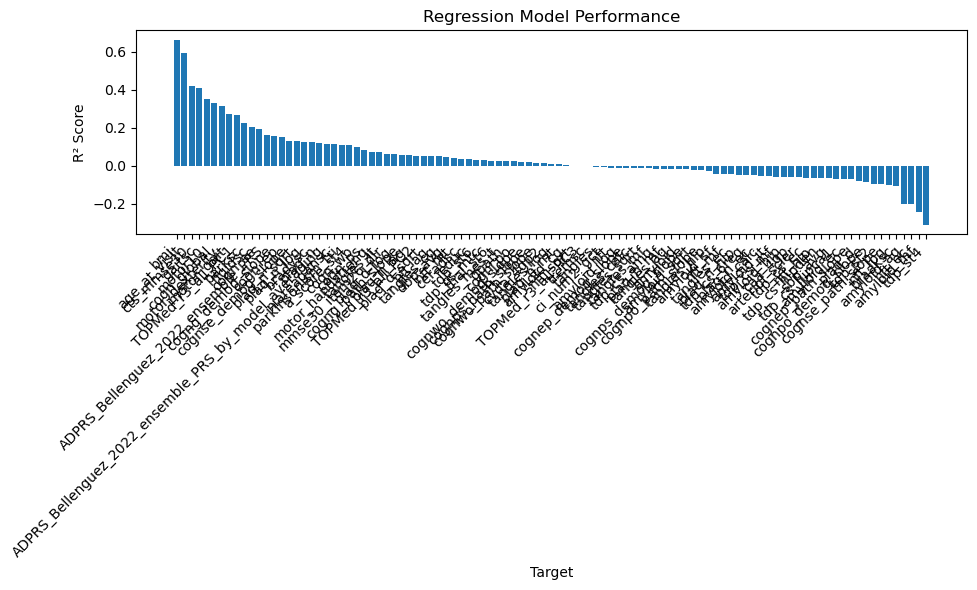

In [19]:
# Display regression results
if reg_df is not None and not reg_df.empty:
    print("\nRegression Results:")
    display(reg_df)
    
    # Plot R2 scores
    plt.figure(figsize=(10, 6))
    plt.bar(reg_df['Target'], reg_df['R2'])
    plt.xlabel('Target')
    plt.ylabel('R² Score')
    plt.title('Regression Model Performance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Classification Results:


,Target,Target ID,Type,Number of samples,Include Covariates,Classes,Accuracy,Precision,Recall,F1,Time (s),Model file
24,apoe_genotype,T0607,Classification,1541,False,6,0.987138,0.987242,0.987138,0.987159,13.416632,./output_20250307/models/T0607_model.pkl
16,mmse30_item17,T0037,Classification,1580,False,2,0.978593,0.981481,0.996865,0.989114,11.491582,./output_20250307/models/T0037_model.pkl
15,mmse30_item18,T0038,Classification,1580,False,2,0.972477,0.975232,0.996835,0.985915,11.212251,./output_20250307/models/T0038_model.pkl
14,msex,T0002,Classification,1611,False,2,0.972136,0.986301,0.900000,0.941176,11.598392,./output_20250307/models/T0002_model.pkl
19,mmse30_item11,T0031,Classification,1602,False,2,0.962500,0.965517,0.996764,0.980892,11.636191,./output_20250307/models/T0031_model.pkl
10,mmse30_item6,T0026,Classification,1603,False,2,0.953271,0.962145,0.990260,0.976000,11.762670,./output_20250307/models/T0026_model.pkl
21,mmse30_item24,T0044,Classification,1562,False,2,0.948171,0.953416,0.993528,0.973059,11.369792,./output_20250307/models/T0044_model.pkl
23,mmse30_item22,T0042,Classification,1589,False,2,0.931677,0.934579,0.996678,0.964630,11.417375,./output_20250307/models/T0042_model.pkl
0,mmse30_item20,T0040,Classification,1563,False,2,0.926984,0.926518,1.000000,0.961857,11.485733,./output_20250307/models/T0040_model.pkl
5,mmse30_item8,T0028,Classification,1603,False,2,0.919003,0.923323,0.993127,0.956954,11.632041,./output_20250307/models/T0028_model.pkl


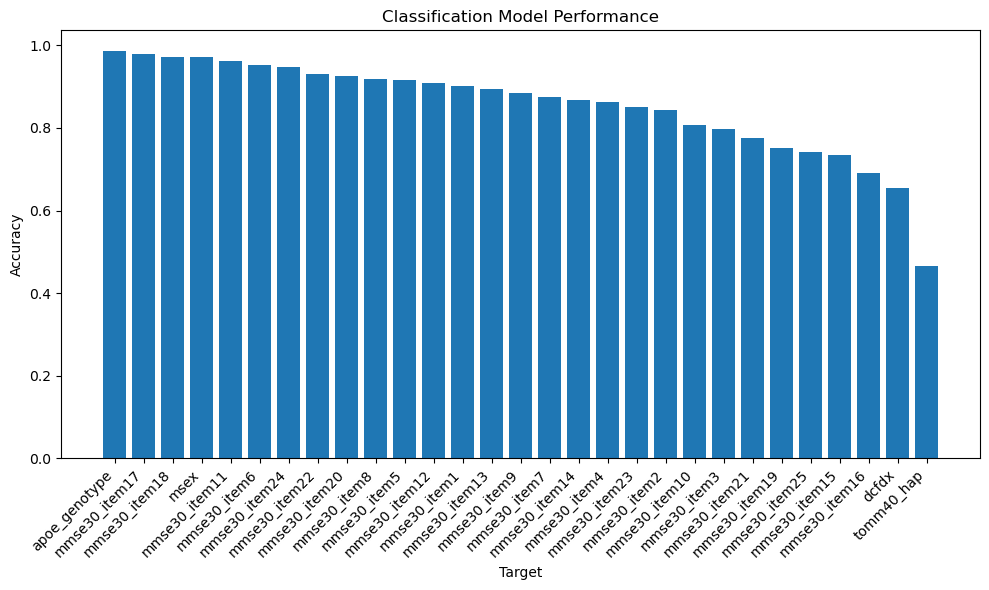

In [20]:
# Display classification results
if cls_df is not None and not cls_df.empty:
    print("\nClassification Results:")
    display(cls_df)
    
    # Plot accuracy scores
    plt.figure(figsize=(10, 6))
    plt.bar(cls_df['Target'], cls_df['Accuracy'])
    plt.xlabel('Target')
    plt.ylabel('Accuracy')
    plt.title('Classification Model Performance')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Examine Feature Importance

In [36]:
# Load feature info for a specific target
if all_results:
    # Get first model's feature file
    feature_file = all_results[0]['Feature file']
    if os.path.exists(feature_file):
        try:
            feature_info = pd.read_csv(feature_file)
            print(f"\nFeature info for {all_results[0]['Target']}:")
            display(feature_info.head(10))
            
            # Count features by type and group
            print("\nFeature counts by type:")
            display(feature_info['feature_type'].value_counts())
            
            if 'feature_group' in feature_info.columns:
                print("\nFeature counts by group:")
                display(feature_info['feature_group'].value_counts())
        except Exception as e:
            print(f"Error loading feature info: {e}")

KeyError: 'Feature file'

## Examine Trained Model

In [37]:
# Load a trained model
if all_results:
    # Get first model file
    model_file = all_results[0]['Model file']
    if os.path.exists(model_file):
        try:
            with open(model_file, 'rb') as f:
                model_data = pickle.load(f)
            
            # Print model info
            print(f"\nModel info for {all_results[0]['Target']}:")
            print(f"Target ID: {model_data['target_id']}")
            print(f"Target type: {model_data['target_type']}")
            print(f"Include covariates: {model_data['include_covariates']}")
            
            # Print other model attributes
            if 'model' in model_data:
                if hasattr(model_data['model'], 'n_estimators'):
                    print(f"Number of estimators: {model_data['model'].n_estimators}")
                if hasattr(model_data['model'], 'device'):
                    print(f"Device: {model_data['model'].device}")
        except Exception as e:
            print(f"Error loading model: {e}")


Model info for mmse30_item7:
Target ID: T0027
Target type: discrete
Include covariates: False
Number of estimators: 8
Device: cuda:0
